In [1]:
import pandas as pd
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.config as config
import src.profile_model_registry as profile_model_registry
import src.profile_tracker as profile_tracker
import src.profile_trainer as profile_trainer

importlib.reload(config)
importlib.reload(profile_model_registry)
importlib.reload(profile_tracker)
importlib.reload(profile_trainer)

from src.profile_trainer import run_profile_training_experiment

print(profile_model_registry.get_profile_dense_models().keys())
print(profile_model_registry.get_profile_nan_friendly_models().keys())

dict_keys(['ridge', 'random_forest', 'xgboost', 'catboost'])
dict_keys(['hist_gbr', 'xgboost'])


get_profile_dense_models

In [2]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\15_min\df_BU_TotActPwr_Academy.parquet"
df_target = pd.read_parquet(path)

In [3]:
df_target.head()

,BU_TotActPwr_Academy,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,dayofweek,is_weekend,hour,month,dayofmonth,minute_of_day,...,BU_TotActPwr_Academy_roll_std_96,BU_TotActPwr_Academy_trend_1_4,BU_TotActPwr_Academy_trend_1_12,BU_TotActPwr_Academy_trend_1_96,BU_TotActPwr_Academy_trend_96_192,BU_TotActPwr_Academy_yesterday_mean,BU_TotActPwr_Academy_yesterday_max,BU_TotActPwr_Academy_yesterday_midday_max,BU_TotActPwr_Academy_yesterday_peak_time_step,BU_TotActPwr_Academy_lastweek_same_day_peak
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-22 00:00:00,5.36067,80.63333,126.00000,-4.30000,2,0,0,10,22,0,...,2.481165,0.24000,0.20734,-0.73833,1.86300,7.011386,12.54667,11.58467,32.0,15.96933
2025-10-22 00:15:00,6.27833,80.20000,122.00000,-5.00000,2,0,0,10,22,15,...,2.485274,0.03034,0.23300,0.00534,1.63700,7.011386,12.54667,11.58467,32.0,15.96933
2025-10-22 00:30:00,5.09133,79.83333,122.00000,-4.66667,2,0,0,10,22,30,...,2.480612,1.16400,0.70866,0.83566,1.82267,7.011386,12.54667,11.58467,32.0,15.96933
2025-10-22 00:45:00,5.77000,79.40000,124.00000,-4.26667,2,0,0,10,22,45,...,2.483211,-0.29834,-0.81934,-0.22167,1.27367,7.011386,12.54667,11.58467,32.0,15.96933
2025-10-22 01:00:00,5.05167,79.03333,125.33333,-4.33333,2,0,1,10,22,60,...,2.480361,0.40933,-0.16200,0.48467,1.55966,7.011386,12.54667,11.58467,32.0,15.96933


In [24]:
from src.profile_tracker import PROFILE_EXPERIMENT_LOG_FILE
from pathlib import Path
import shutil

print(PROFILE_EXPERIMENT_LOG_FILE)
print(PROFILE_EXPERIMENT_LOG_FILE.exists())

if PROFILE_EXPERIMENT_LOG_FILE.exists():
    backup_path = PROFILE_EXPERIMENT_LOG_FILE.with_name(
        PROFILE_EXPERIMENT_LOG_FILE.stem + "_corrupted_backup" + PROFILE_EXPERIMENT_LOG_FILE.suffix
    )
    shutil.move(PROFILE_EXPERIMENT_LOG_FILE, backup_path)
    print("Moved corrupted log to:", backup_path)

C:\Data_analysis\Thesis\outputs\profile_forecasting\logs\profile_experiment_log.csv
True
Moved corrupted log to: C:\Data_analysis\Thesis\outputs\profile_forecasting\logs\profile_experiment_log_corrupted_backup.csv


In [20]:
from src.emd_features import add_emd_features_at_issue_times

target_col = "BU_TotActPwr_Academy"

df_emd, emd_feature_cols = add_emd_features_at_issue_times(
    df=df_target,
    target_col=target_col,
    history_steps=96 * 7,
    issue_hour=23,
    issue_minute=45,
    max_imfs=4,
    min_history_steps=96,
)

print("Number of EMD features:", len(emd_feature_cols))
print(emd_feature_cols)

Number of EMD features: 27
['BU_TotActPwr_Academy_emd_n_imfs', 'BU_TotActPwr_Academy_emd_imf1_last', 'BU_TotActPwr_Academy_emd_imf1_mean', 'BU_TotActPwr_Academy_emd_imf1_std', 'BU_TotActPwr_Academy_emd_imf1_energy_ratio', 'BU_TotActPwr_Academy_emd_imf1_amplitude', 'BU_TotActPwr_Academy_emd_imf2_last', 'BU_TotActPwr_Academy_emd_imf2_mean', 'BU_TotActPwr_Academy_emd_imf2_std', 'BU_TotActPwr_Academy_emd_imf2_energy_ratio', 'BU_TotActPwr_Academy_emd_imf2_amplitude', 'BU_TotActPwr_Academy_emd_imf3_last', 'BU_TotActPwr_Academy_emd_imf3_mean', 'BU_TotActPwr_Academy_emd_imf3_std', 'BU_TotActPwr_Academy_emd_imf3_energy_ratio', 'BU_TotActPwr_Academy_emd_imf3_amplitude', 'BU_TotActPwr_Academy_emd_imf4_last', 'BU_TotActPwr_Academy_emd_imf4_mean', 'BU_TotActPwr_Academy_emd_imf4_std', 'BU_TotActPwr_Academy_emd_imf4_energy_ratio', 'BU_TotActPwr_Academy_emd_imf4_amplitude', 'BU_TotActPwr_Academy_emd_residual_last', 'BU_TotActPwr_Academy_emd_residual_mean', 'BU_TotActPwr_Academy_emd_residual_std', 'BU_

In [21]:
target_col = "BU_TotActPwr_Academy"

base_feature_cols = [
    c for c in df_emd.columns
    if c != target_col and not c.startswith(f"{target_col}_emd_")
]

feature_cols_with_emd = base_feature_cols + emd_feature_cols
feature_cols_with_emd = list(dict.fromkeys(feature_cols_with_emd))

print("Base features:", len(base_feature_cols))
print("EMD features:", len(emd_feature_cols))
print("Features with EMD:", len(feature_cols_with_emd))

Base features: 48
EMD features: 27
Features with EMD: 75


In [22]:
feature_cols_with_emd[:10], feature_cols_with_emd[-10:]

(['BA_Soc',
  'PV_WS_AirTemp',
  'PV_WS_Radiation',
  'dayofweek',
  'is_weekend',
  'hour',
  'month',
  'dayofmonth',
  'minute_of_day',
  'sin_tod'],
 ['BU_TotActPwr_Academy_emd_imf4_mean',
  'BU_TotActPwr_Academy_emd_imf4_std',
  'BU_TotActPwr_Academy_emd_imf4_energy_ratio',
  'BU_TotActPwr_Academy_emd_imf4_amplitude',
  'BU_TotActPwr_Academy_emd_residual_last',
  'BU_TotActPwr_Academy_emd_residual_mean',
  'BU_TotActPwr_Academy_emd_residual_std',
  'BU_TotActPwr_Academy_emd_residual_trend',
  'BU_TotActPwr_Academy_emd_high_freq_energy_ratio',
  'BU_TotActPwr_Academy_emd_used_imf_energy_ratio'])

In [25]:
from src.profile_trainer import run_profile_training_experiment

emd_results, emd_horizon = run_profile_training_experiment(
    df=df_emd,
    target_col=target_col,
    feature_cols=feature_cols_with_emd,
    dataset_name="profile_with_emd_features",
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    selected_models=["xgboost"],
    drop_feature_nan=True,
)

emd_results

Training xgboost for day-ahead profile forecasting: BU_TotActPwr_Academy [dense]


,run_id,timestamp,task_type,dataset_name,feature_set_name,data_mode,target,model_name,model_params,n_features,...,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,model_path,prediction_path,horizon_metrics_path,plot_path,params_path
0,run_20260424_162233_e58dfd5b,2026-04-24 16:22:33,day_ahead_profile_forecasting,profile_with_emd_features,default_features,dense,BU_TotActPwr_Academy,xgboost,"{""estimator__objective"": ""reg:squarederror"", ""...",75,...,2.337571,4.085214,20.349513,21.475187,0.689564,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [26]:
baseline_results, baseline_horizon = run_profile_training_experiment(
    df=df_emd,
    target_col=target_col,
    feature_cols=base_feature_cols,
    dataset_name="profile_baseline_no_emd",
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    selected_models=["xgboost"],
    drop_feature_nan=True,
)

baseline_results

Training xgboost for day-ahead profile forecasting: BU_TotActPwr_Academy [dense]


,run_id,timestamp,task_type,dataset_name,feature_set_name,data_mode,target,model_name,model_params,n_features,...,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,model_path,prediction_path,horizon_metrics_path,plot_path,params_path
0,run_20260424_162349_0a245900,2026-04-24 16:23:49,day_ahead_profile_forecasting,profile_baseline_no_emd,default_features,dense,BU_TotActPwr_Academy,xgboost,"{""estimator__objective"": ""reg:squarederror"", ""...",48,...,2.290314,3.874775,20.734754,21.849678,0.720723,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [27]:
import pandas as pd

comparison = pd.concat([
    baseline_results.assign(experiment="baseline_no_emd"),
    emd_results.assign(experiment="with_emd"),
], ignore_index=True)

comparison[[
    "experiment",
    "model_name",
    "n_features",
    "n_train_days",
    "n_val_days",
    "n_test_days",
    "test_MAE",
    "test_RMSE",
    "test_MAPE",
    "test_sMAPE",
    "test_R2",
]]

,experiment,model_name,n_features,n_train_days,n_val_days,n_test_days,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2
0,baseline_no_emd,xgboost,48,76,16,17,2.290314,3.874775,20.734754,21.849678,0.720723
1,with_emd,xgboost,75,76,16,17,2.337571,4.085214,20.349513,21.475187,0.689564


In [ ]:
import pandas as pd

comparison = pd.concat([
    baseline_results.assign(experiment="baseline_no_emd"),
    emd_results.assign(experiment="with_emd"),
], ignore_index=True)

comparison[[
    "experiment",
    "model_name",
    "n_features",
    "n_train_days",
    "n_val_days",
    "n_test_days",
    "test_MAE",
    "test_RMSE",
    "test_MAPE",
    "test_sMAPE",
    "test_R2",
]]

In [108]:
import numpy as np
import pandas as pd

from src.profile_dataset_builder import build_day_ahead_profile_dataset
from src.splitter import time_based_split

# ==========================================
# 1. target and feature list
# ==========================================
target_col = "BU_TotActPwr_Academy"

feature_cols = [
    'BA_Soc',
    'PV_WS_AirTemp',
    'PV_WS_Radiation',
    'dayofweek',
    'is_weekend',
    'hour',
    'month',
    'dayofmonth',
    'minute_of_day',
    'sin_tod',
    'cos_tod',
    'sin_dow',
    'cos_dow',
    'is_business_hours',
    'is_midday_peak_window',
    'is_midday_weekday_peak',
    'BU_TotActPwr_Academy_lag_1',
    'BU_TotActPwr_Academy_lag_2',
    'BU_TotActPwr_Academy_lag_3',
    'BU_TotActPwr_Academy_lag_4',
    'BU_TotActPwr_Academy_lag_8',
    'BU_TotActPwr_Academy_lag_12',
    'BU_TotActPwr_Academy_lag_24',
    'BU_TotActPwr_Academy_lag_48',
    'BU_TotActPwr_Academy_lag_96',
    'BU_TotActPwr_Academy_lag_192',
    'BU_TotActPwr_Academy_lag_288',
    'BU_TotActPwr_Academy_lag_672',
    'BU_TotActPwr_Academy_roll_mean_4',
    'BU_TotActPwr_Academy_roll_mean_12',
    'BU_TotActPwr_Academy_roll_mean_24',
    'BU_TotActPwr_Academy_roll_mean_48',
    'BU_TotActPwr_Academy_roll_mean_96',
    'BU_TotActPwr_Academy_roll_mean_288',
    'BU_TotActPwr_Academy_roll_std_12',
    'BU_TotActPwr_Academy_roll_std_24',
    'BU_TotActPwr_Academy_roll_std_48',
    'BU_TotActPwr_Academy_roll_std_96',
    'BU_TotActPwr_Academy_trend_1_4',
    'BU_TotActPwr_Academy_trend_1_12',
    'BU_TotActPwr_Academy_trend_1_96',
    'BU_TotActPwr_Academy_trend_96_192',
    'BU_TotActPwr_Academy_yesterday_mean',
    'BU_TotActPwr_Academy_yesterday_max',
    'BU_TotActPwr_Academy_yesterday_midday_max',
    'BU_TotActPwr_Academy_yesterday_peak_time_step',
    'BU_TotActPwr_Academy_lastweek_same_day_peak',
]

# ==========================================
# 2. prepare dataframe
# ==========================================
df_profile = df_target.copy().sort_index()

if not isinstance(df_profile.index, pd.DatetimeIndex):
    raise ValueError("df_target index must be a DatetimeIndex")

df_profile["slot_15min"] = df_profile.index.hour * 4 + df_profile.index.minute // 15
if "slot_15min" not in feature_cols:
    feature_cols = feature_cols + ["slot_15min"]

# ==========================================
# 3. build normal day-ahead profile dataset
#    X = issue-time features
#    Y = next 96 target values
# ==========================================
X, Y = build_day_ahead_profile_dataset(
    df_profile,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_feature_nan=False,
    drop_target_nan=True,
)

dataset = pd.concat([X, Y], axis=1).sort_index()

print("Full profile dataset shape:", dataset.shape)

# ==========================================
# 4. chronological split first
#    important: define specialist days using TRAIN only
# ==========================================
train_df, val_df, test_df = time_based_split(
    dataset,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)

print("train:", train_df.shape)
print("val  :", val_df.shape)
print("test :", test_df.shape)

# ==========================================
# 5. define day-level difficulty / high-load score
#    here we use next-day maximum load as simple specialist criterion
# ==========================================
y_cols = list(Y.columns)

train_day_max = train_df[y_cols].max(axis=1)
train_day_mean = train_df[y_cols].mean(axis=1)
train_day_energy_proxy = train_df[y_cols].sum(axis=1)

# choose threshold from TRAIN only
specialist_quantile = 0.80
specialist_threshold = train_day_max.quantile(specialist_quantile)

print("\nSpecialist threshold based on train next-day max")
print(f"quantile = {specialist_quantile:.2f}")
print(f"threshold = {specialist_threshold:.4f}")

# ==========================================
# 6. mark specialist high-load days
# ==========================================
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["is_specialist_day"] = (train_day_max >= specialist_threshold).astype(int)

# for val/test, we only create the TRUE label for later analysis
# do not use these true labels for prediction-time routing later
val_df["is_specialist_day_true"] = (val_df[y_cols].max(axis=1) >= specialist_threshold).astype(int)
test_df["is_specialist_day_true"] = (test_df[y_cols].max(axis=1) >= specialist_threshold).astype(int)

print("\nTrain specialist-day counts:")
print(train_df["is_specialist_day"].value_counts())

print("\nVal true specialist-day counts:")
print(val_df["is_specialist_day_true"].value_counts())

print("\nTest true specialist-day counts:")
print(test_df["is_specialist_day_true"].value_counts())

# ==========================================
# 7. build datasets for hybrid training
# ==========================================
general_train_df = train_df.copy()
specialist_train_df = train_df[train_df["is_specialist_day"] == 1].copy()

print("\nGeneral train shape:", general_train_df.shape)
print("Specialist train shape:", specialist_train_df.shape)

if len(specialist_train_df) < 10:
    print("\nWARNING: specialist train set is very small.")
    print("You may want to lower specialist_quantile from 0.80 to 0.75 or 0.70.")

# ==========================================
# 8. prepare X/Y blocks
# ==========================================
X_train_general = general_train_df[feature_cols].copy()
Y_train_general = general_train_df[y_cols].copy()

X_train_specialist = specialist_train_df[feature_cols].copy()
Y_train_specialist = specialist_train_df[y_cols].copy()

X_val = val_df[feature_cols].copy()
Y_val = val_df[y_cols].copy()

X_test = test_df[feature_cols].copy()
Y_test = test_df[y_cols].copy()

# drop rows with NaNs in features
general_mask = X_train_general.notna().all(axis=1)
specialist_mask = X_train_specialist.notna().all(axis=1)
val_mask = X_val.notna().all(axis=1)
test_mask = X_test.notna().all(axis=1)

X_train_general = X_train_general.loc[general_mask]
Y_train_general = Y_train_general.loc[general_mask]

X_train_specialist = X_train_specialist.loc[specialist_mask]
Y_train_specialist = Y_train_specialist.loc[specialist_mask]

X_val = X_val.loc[val_mask]
Y_val = Y_val.loc[val_mask]
val_df = val_df.loc[val_mask]

X_test = X_test.loc[test_mask]
Y_test = Y_test.loc[test_mask]
test_df = test_df.loc[test_mask]

print("\nAfter feature-NaN filtering")
print("X_train_general   :", X_train_general.shape, "Y_train_general   :", Y_train_general.shape)
print("X_train_specialist:", X_train_specialist.shape, "Y_train_specialist:", Y_train_specialist.shape)
print("X_val             :", X_val.shape, "Y_val             :", Y_val.shape)
print("X_test            :", X_test.shape, "Y_test            :", Y_test.shape)

# ==========================================
# 9. save artifacts for next step
# ==========================================
hybrid_profile_artifacts = {
    "target_col": target_col,
    "feature_cols": feature_cols,
    "y_cols": y_cols,
    "specialist_quantile": specialist_quantile,
    "specialist_threshold": specialist_threshold,
    "X_train_general": X_train_general,
    "Y_train_general": Y_train_general,
    "X_train_specialist": X_train_specialist,
    "Y_train_specialist": Y_train_specialist,
    "X_val": X_val,
    "Y_val": Y_val,
    "X_test": X_test,
    "Y_test": Y_test,
    "val_df": val_df,
    "test_df": test_df,
}

print("\nHybrid preparation done.")

Full profile dataset shape: (109, 144)
train: (76, 144)
val  : (16, 144)
test : (17, 144)

Specialist threshold based on train next-day max
quantile = 0.80
threshold = 21.6783

Train specialist-day counts:
is_specialist_day
0    60
1    16
Name: count, dtype: int64

Val true specialist-day counts:
is_specialist_day_true
0    12
1     4
Name: count, dtype: int64

Test true specialist-day counts:
is_specialist_day_true
1    9
0    8
Name: count, dtype: int64

General train shape: (76, 145)
Specialist train shape: (16, 145)

After feature-NaN filtering
X_train_general   : (76, 48) Y_train_general   : (76, 96)
X_train_specialist: (16, 48) Y_train_specialist: (16, 96)
X_val             : (16, 48) Y_val             : (16, 96)
X_test            : (17, 48) Y_test            : (17, 96)

Hybrid preparation done.


In [110]:
import numpy as np
import pandas as pd

from src.profile_model_registry import get_profile_dense_models
from src.profile_metrics import evaluate_profile_global, evaluate_profile_by_horizon

# ==========================================
# 1. load prepared artifacts
# ==========================================
X_train_general = hybrid_profile_artifacts["X_train_general"]
Y_train_general = hybrid_profile_artifacts["Y_train_general"]

X_train_specialist = hybrid_profile_artifacts["X_train_specialist"]
Y_train_specialist = hybrid_profile_artifacts["Y_train_specialist"]

X_val = hybrid_profile_artifacts["X_val"]
Y_val = hybrid_profile_artifacts["Y_val"]

X_test = hybrid_profile_artifacts["X_test"]
Y_test = hybrid_profile_artifacts["Y_test"]

val_df = hybrid_profile_artifacts["val_df"]
test_df = hybrid_profile_artifacts["test_df"]

target_col = hybrid_profile_artifacts["target_col"]
specialist_threshold = hybrid_profile_artifacts["specialist_threshold"]

# ==========================================
# 2. train general model
# ==========================================
profile_models = get_profile_dense_models(random_state=42)

general_model = profile_models["ridge"]   # can try multi_ridge / multi_random_forest later
specialist_model = profile_models["xgboost"]

print("Training general model...")
general_model.fit(X_train_general, Y_train_general)

print("Training specialist model...")
specialist_model.fit(X_train_specialist, Y_train_specialist)

# ==========================================
# 3. get predictions from both models
# ==========================================
val_pred_general = general_model.predict(X_val)
test_pred_general = general_model.predict(X_test)

val_pred_specialist = specialist_model.predict(X_val)
test_pred_specialist = specialist_model.predict(X_test)

# ==========================================
# 4. routing rule
#    since we cannot use true future max at prediction time,
#    use general model's predicted next-day max as router
# ==========================================
val_pred_general_daymax = val_pred_general.max(axis=1)
test_pred_general_daymax = test_pred_general.max(axis=1)

val_use_specialist = (val_pred_general_daymax >= specialist_threshold)
test_use_specialist = (test_pred_general_daymax >= specialist_threshold)

print("\nRouting counts")
print("VAL specialist routed:", int(val_use_specialist.sum()), "out of", len(val_use_specialist))
print("TEST specialist routed:", int(test_use_specialist.sum()), "out of", len(test_use_specialist))

# ==========================================
# 5. hard-switch hybrid forecast
#    use specialist prediction for routed days, else general
# ==========================================
val_pred_hybrid = val_pred_general.copy()
test_pred_hybrid = test_pred_general.copy()

val_pred_hybrid[val_use_specialist] = val_pred_specialist[val_use_specialist]
test_pred_hybrid[test_use_specialist] = test_pred_specialist[test_use_specialist]

# ==========================================
# 6. optional blended hybrid
#    if specialist is too unstable, blending can be safer
# ==========================================
blend_weight = 0.50   # 0.0 = only general, 1.0 = only specialist on routed days

val_pred_blend = val_pred_general.copy()
test_pred_blend = test_pred_general.copy()

val_pred_blend[val_use_specialist] = (
    (1 - blend_weight) * val_pred_general[val_use_specialist]
    + blend_weight * val_pred_specialist[val_use_specialist]
)

test_pred_blend[test_use_specialist] = (
    (1 - blend_weight) * test_pred_general[test_use_specialist]
    + blend_weight * test_pred_specialist[test_use_specialist]
)

# keep non-negative
val_pred_general = np.clip(val_pred_general, a_min=0.0, a_max=None)
test_pred_general = np.clip(test_pred_general, a_min=0.0, a_max=None)

val_pred_hybrid = np.clip(val_pred_hybrid, a_min=0.0, a_max=None)
test_pred_hybrid = np.clip(test_pred_hybrid, a_min=0.0, a_max=None)

val_pred_blend = np.clip(val_pred_blend, a_min=0.0, a_max=None)
test_pred_blend = np.clip(test_pred_blend, a_min=0.0, a_max=None)

# ==========================================
# 7. evaluate all three
# ==========================================
general_val_metrics = evaluate_profile_global(Y_val, val_pred_general)
general_test_metrics = evaluate_profile_global(Y_test, test_pred_general)

hybrid_val_metrics = evaluate_profile_global(Y_val, val_pred_hybrid)
hybrid_test_metrics = evaluate_profile_global(Y_test, test_pred_hybrid)

blend_val_metrics = evaluate_profile_global(Y_val, val_pred_blend)
blend_test_metrics = evaluate_profile_global(Y_test, test_pred_blend)

print("\nGeneral VAL:", general_val_metrics)
print("General TEST:", general_test_metrics)

print("\nHard-switch Hybrid VAL:", hybrid_val_metrics)
print("Hard-switch Hybrid TEST:", hybrid_test_metrics)

print("\nBlended Hybrid VAL:", blend_val_metrics)
print("Blended Hybrid TEST:", blend_test_metrics)

# ==========================================
# 8. compare in one table
# ==========================================
comparison_df = pd.DataFrame([
    {"method": "general_profile", **general_test_metrics},
    {"method": "hard_switch_hybrid", **hybrid_test_metrics},
    {"method": "blended_hybrid", **blend_test_metrics},
])

print("\nTEST comparison summary")
print(comparison_df)

# ==========================================
# 9. horizon-wise comparison
# ==========================================
general_horizon = evaluate_profile_by_horizon(Y_test, test_pred_general)
hybrid_horizon = evaluate_profile_by_horizon(Y_test, test_pred_hybrid)
blend_horizon = evaluate_profile_by_horizon(Y_test, test_pred_blend)

# ==========================================
# 10. keep artifacts for plots / later analysis
# ==========================================
hybrid_results = {
    "general_model": general_model,
    "specialist_model": specialist_model,
    "X_test": X_test,
    "Y_test": Y_test,
    "test_pred_general": test_pred_general,
    "test_pred_hybrid": test_pred_hybrid,
    "test_pred_blend": test_pred_blend,
    "test_use_specialist": test_use_specialist,
    "specialist_threshold": specialist_threshold,
    "comparison_df": comparison_df,
    "general_horizon": general_horizon,
    "hybrid_horizon": hybrid_horizon,
    "blend_horizon": blend_horizon,
}

print("\nHybrid experiment done.")

Training general model...
Training specialist model...

Routing counts
VAL specialist routed: 4 out of 16
TEST specialist routed: 7 out of 17

General VAL: {'MAE': 2.3537211466431147, 'RMSE': 3.996471758052132, 'MAPE': 33.684432545905715, 'sMAPE': 26.066072018801474, 'R2': 0.5278178591257456}
General TEST: {'MAE': 2.082533927879778, 'RMSE': 3.2713234607990667, 'MAPE': 23.21614887055616, 'sMAPE': 21.266330222929497, 'R2': 0.8009375549593132}

Hard-switch Hybrid VAL: {'MAE': 2.1976596097638272, 'RMSE': 3.5720541702098227, 'MAPE': 31.203167681159805, 'sMAPE': 25.177981607946975, 'R2': 0.6227822389094668}
Hard-switch Hybrid TEST: {'MAE': 2.2799727311229647, 'RMSE': 3.679417826795838, 'MAPE': 23.702289996712587, 'sMAPE': 22.214229463995608, 'R2': 0.7481739960990059}

Blended Hybrid VAL: {'MAE': 2.2475826703124806, 'RMSE': 3.737744987468248, 'MAPE': 32.0325989435249, 'sMAPE': 25.21787061871897, 'R2': 0.586975897771874}
Blended Hybrid TEST: {'MAE': 2.103201689540788, 'RMSE': 3.370529388216014

In [104]:
import numpy as np
import pandas as pd

from src.profile_dataset_builder import build_day_ahead_profile_dataset
from src.profile_model_registry import get_profile_dense_models
from src.profile_metrics import evaluate_profile_global, evaluate_profile_by_horizon
from src.splitter import time_based_split

# ==========================================
# 1. target and features
# ==========================================
target_col = "BU_TotActPwr_Academy"

feature_cols = [
    'BA_Soc',
    'PV_WS_AirTemp',
    'PV_WS_Radiation',
    'dayofweek',
    'is_weekend',
    'hour',
    'month',
    'dayofmonth',
    'minute_of_day',
    'sin_tod',
    'cos_tod',
    'sin_dow',
    'cos_dow',
    'is_business_hours',
    'is_midday_peak_window',
    'is_midday_weekday_peak',
    'BU_TotActPwr_Academy_lag_1',
    'BU_TotActPwr_Academy_lag_2',
    'BU_TotActPwr_Academy_lag_3',
    'BU_TotActPwr_Academy_lag_4',
    'BU_TotActPwr_Academy_lag_8',
    'BU_TotActPwr_Academy_lag_12',
    'BU_TotActPwr_Academy_lag_24',
    'BU_TotActPwr_Academy_lag_48',
    'BU_TotActPwr_Academy_lag_96',
    'BU_TotActPwr_Academy_lag_192',
    'BU_TotActPwr_Academy_lag_288',
    'BU_TotActPwr_Academy_lag_672',
    'BU_TotActPwr_Academy_roll_mean_4',
    'BU_TotActPwr_Academy_roll_mean_12',
    'BU_TotActPwr_Academy_roll_mean_24',
    'BU_TotActPwr_Academy_roll_mean_48',
    'BU_TotActPwr_Academy_roll_mean_96',
    'BU_TotActPwr_Academy_roll_mean_288',
    'BU_TotActPwr_Academy_roll_std_12',
    'BU_TotActPwr_Academy_roll_std_24',
    'BU_TotActPwr_Academy_roll_std_48',
    'BU_TotActPwr_Academy_roll_std_96',
    'BU_TotActPwr_Academy_trend_1_4',
    'BU_TotActPwr_Academy_trend_1_12',
    'BU_TotActPwr_Academy_trend_1_96',
    'BU_TotActPwr_Academy_trend_96_192',
    'BU_TotActPwr_Academy_yesterday_mean',
    'BU_TotActPwr_Academy_yesterday_max',
    'BU_TotActPwr_Academy_yesterday_midday_max',
    'BU_TotActPwr_Academy_yesterday_peak_time_step',
    'BU_TotActPwr_Academy_lastweek_same_day_peak',
]

# add discrete 15-min slot if missing
df_profile = df_imputed.copy().sort_index()
df_profile["slot_15min"] = df_profile.index.hour * 4 + df_profile.index.minute // 15
if "slot_15min" not in feature_cols:
    feature_cols = feature_cols + ["slot_15min"]

# ==========================================
# 2. build standard direct day-ahead profile dataset
# ==========================================
X, Y = build_day_ahead_profile_dataset(
    df_profile,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_feature_nan=False,
    drop_target_nan=True,
)

dataset = pd.concat([X, Y], axis=1).sort_index()

train_df, val_df, test_df = time_based_split(
    dataset,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)

y_cols = list(Y.columns)

X_train = train_df[feature_cols].copy()
Y_train = train_df[y_cols].copy()

X_val = val_df[feature_cols].copy()
Y_val = val_df[y_cols].copy()

X_test = test_df[feature_cols].copy()
Y_test = test_df[y_cols].copy()

# drop rows with NaNs in features
train_mask = X_train.notna().all(axis=1)
val_mask   = X_val.notna().all(axis=1)
test_mask  = X_test.notna().all(axis=1)

X_train = X_train.loc[train_mask]
Y_train = Y_train.loc[train_mask]

X_val = X_val.loc[val_mask]
Y_val = Y_val.loc[val_mask]

X_test = X_test.loc[test_mask]
Y_test = Y_test.loc[test_mask]

print("Direct profile dataset shapes")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape, "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape, "Y_test :", Y_test.shape)

# ==========================================
# 3. train base direct profile model
# ==========================================
profile_models = get_profile_dense_models(random_state=42)
base_model = profile_models["xgboost"]   # can also try multi_ridge / multi_random_forest

print("\nTraining base profile model...")
base_model.fit(X_train, Y_train)

val_base_pred = base_model.predict(X_val)
test_base_pred = base_model.predict(X_test)

base_val_metrics = evaluate_profile_global(Y_val, val_base_pred)
base_test_metrics = evaluate_profile_global(Y_test, test_base_pred)

print("\nBase VAL metrics:", base_val_metrics)
print("Base TEST metrics:", base_test_metrics)

# ==========================================
# 4. define peak mask from TRAIN truth
#    peak threshold = 85th percentile of all train target points
# ==========================================
peak_quantile = 0.85
peak_threshold = np.nanquantile(Y_train.values, peak_quantile)

print("\nPeak threshold (train {:.0%} quantile): {:.4f}".format(peak_quantile, peak_threshold))

# ==========================================
# 5. train correction target = residuals of base model
# ==========================================
train_base_pred = base_model.predict(X_train)
train_residual = Y_train.values - train_base_pred   # true - pred

# only keep residuals for peak points, zero elsewhere
peak_mask_train = (Y_train.values >= peak_threshold)
train_peak_residual = np.where(peak_mask_train, train_residual, 0.0)

# ==========================================
# 6. train second model to predict peak residual correction
# ==========================================
correction_model = profile_models["xgboost"]

print("Training peak correction model...")
correction_model.fit(X_train, train_peak_residual)

val_corr_pred = correction_model.predict(X_val)
test_corr_pred = correction_model.predict(X_test)

# ==========================================
# 7. apply correction only where base prediction looks peak-like
#    use predicted values, not true values, to avoid leakage
# ==========================================
peak_mask_val_pred = (val_base_pred >= peak_threshold)
peak_mask_test_pred = (test_base_pred >= peak_threshold)

val_final_pred = val_base_pred + np.where(peak_mask_val_pred, val_corr_pred, 0.0)
test_final_pred = test_base_pred + np.where(peak_mask_test_pred, test_corr_pred, 0.0)

# optional non-negative clipping
val_final_pred = np.clip(val_final_pred, a_min=0.0, a_max=None)
test_final_pred = np.clip(test_final_pred, a_min=0.0, a_max=None)

# ==========================================
# 8. evaluate corrected forecast
# ==========================================
corr_val_metrics = evaluate_profile_global(Y_val, val_final_pred)
corr_test_metrics = evaluate_profile_global(Y_test, test_final_pred)

print("\nCorrected VAL metrics:", corr_val_metrics)
print("Corrected TEST metrics:", corr_test_metrics)

# horizon-wise metrics
base_test_horizon = evaluate_profile_by_horizon(Y_test, test_base_pred)
corr_test_horizon = evaluate_profile_by_horizon(Y_test, test_final_pred)

# ==========================================
# 9. compare base vs corrected
# ==========================================
comparison_df = pd.DataFrame([
    {"method": "base_direct_profile", **base_test_metrics},
    {"method": "peak_corrected_profile", **corr_test_metrics},
])

print("\nComparison summary")
print(comparison_df)

# ==========================================
# 10. keep results for later plots
# ==========================================
peak_correction_artifacts = {
    "base_model": base_model,
    "correction_model": correction_model,
    "X_test": X_test,
    "Y_test": Y_test,
    "test_base_pred": test_base_pred,
    "test_final_pred": test_final_pred,
    "peak_threshold": peak_threshold,
    "base_test_horizon": base_test_horizon,
    "corr_test_horizon": corr_test_horizon,
    "comparison_df": comparison_df,
}

Direct profile dataset shapes
X_train: (76, 48) Y_train: (76, 96)
X_val  : (16, 48) Y_val  : (16, 96)
X_test : (17, 48) Y_test : (17, 96)

Training base profile model...

Base VAL metrics: {'MAE': 1.891474033257067, 'RMSE': 3.1426815674757234, 'MAPE': 25.30916459207167, 'sMAPE': 23.06584194869987, 'R2': 0.7080175038584664}
Base TEST metrics: {'MAE': 2.2998586804828456, 'RMSE': 3.888588106255806, 'MAPE': 20.843733638546293, 'sMAPE': 21.954684434739967, 'R2': 0.7187281662590408}

Peak threshold (train 85% quantile): 13.1723
Training peak correction model...

Corrected VAL metrics: {'MAE': 1.8904402782949805, 'RMSE': 3.1401567402895805, 'MAPE': 25.309329860884276, 'sMAPE': 23.058406078416205, 'R2': 0.708486472281325}
Corrected TEST metrics: {'MAE': 2.2976647918070063, 'RMSE': 3.8825655904457794, 'MAPE': 20.841082118507412, 'sMAPE': 21.941702615557205, 'R2': 0.7195987404838193}

Comparison summary
                   method       MAE      RMSE       MAPE      sMAPE        R2
0     base_dire

In [98]:
import numpy as np
import pandas as pd

from src.profile_dataset_builder import build_day_ahead_profile_dataset

# ==========================================
# 1. target and feature list
# ==========================================
target_col = "BU_TotActPwr_Academy"

feature_cols = [
    'BA_Soc',
    'PV_WS_AirTemp',
    'PV_WS_Radiation',
    'dayofweek',
    'is_weekend',
    'hour',
    'month',
    'dayofmonth',
    'minute_of_day',
    'sin_tod',
    'cos_tod',
    'sin_dow',
    'cos_dow',
    'is_business_hours',
    'is_midday_peak_window',
    'is_midday_weekday_peak',
    'BU_TotActPwr_Academy_lag_1',
    'BU_TotActPwr_Academy_lag_2',
    'BU_TotActPwr_Academy_lag_3',
    'BU_TotActPwr_Academy_lag_4',
    'BU_TotActPwr_Academy_lag_8',
    'BU_TotActPwr_Academy_lag_12',
    'BU_TotActPwr_Academy_lag_24',
    'BU_TotActPwr_Academy_lag_48',
    'BU_TotActPwr_Academy_lag_96',
    'BU_TotActPwr_Academy_lag_192',
    'BU_TotActPwr_Academy_lag_288',
    'BU_TotActPwr_Academy_lag_672',
    'BU_TotActPwr_Academy_roll_mean_4',
    'BU_TotActPwr_Academy_roll_mean_12',
    'BU_TotActPwr_Academy_roll_mean_24',
    'BU_TotActPwr_Academy_roll_mean_48',
    'BU_TotActPwr_Academy_roll_mean_96',
    'BU_TotActPwr_Academy_roll_mean_288',
    'BU_TotActPwr_Academy_roll_std_12',
    'BU_TotActPwr_Academy_roll_std_24',
    'BU_TotActPwr_Academy_roll_std_48',
    'BU_TotActPwr_Academy_roll_std_96',
    'BU_TotActPwr_Academy_trend_1_4',
    'BU_TotActPwr_Academy_trend_1_12',
    'BU_TotActPwr_Academy_trend_1_96',
    'BU_TotActPwr_Academy_trend_96_192',
    'BU_TotActPwr_Academy_yesterday_mean',
    'BU_TotActPwr_Academy_yesterday_max',
    'BU_TotActPwr_Academy_yesterday_midday_max',
    'BU_TotActPwr_Academy_yesterday_peak_time_step',
    'BU_TotActPwr_Academy_lastweek_same_day_peak',
]

# ==========================================
# 2. prepare dataframe
# ==========================================
df_profile = df_imputed.copy().sort_index()

if not isinstance(df_profile.index, pd.DatetimeIndex):
    raise ValueError("df_imputed index must be a DatetimeIndex")

# add slot_15min if you do not already have it
df_profile["slot_15min"] = df_profile.index.hour * 4 + df_profile.index.minute // 15
if "slot_15min" not in feature_cols:
    feature_cols = feature_cols + ["slot_15min"]

print("Prepared df_profile shape:", df_profile.shape)

# ==========================================
# 3. build standard day-ahead profile dataset
#    X: issue-time features
#    Y_raw: next 96 raw target values
# ==========================================
X, Y_raw = build_day_ahead_profile_dataset(
    df_profile,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_feature_nan=False,
    drop_target_nan=True,
)

print("X shape:", X.shape)
print("Y_raw shape:", Y_raw.shape)

# ==========================================
# 4. build daily energy target
#    Since data is 15-min, daily energy in kWh is:
#    sum(power_kW * 0.25h)
# ==========================================
step_hours = 15 / 60.0
daily_energy = Y_raw.sum(axis=1) * step_hours
E = daily_energy.rename("daily_energy_kwh")

# ==========================================
# 5. build normalized shape target
#    shape rows sum to 1
# ==========================================
shape_den = Y_raw.sum(axis=1).replace(0, np.nan)
S = Y_raw.div(shape_den, axis=0)

# rename shape columns for clarity
S.columns = [f"shape_tplus_{i:03d}" for i in range(1, 97)]

# ==========================================
# 6. drop invalid rows if any
#    (for example if a day has zero total load)
# ==========================================
valid_mask = E.notna() & S.notna().all(axis=1)

X_es = X.loc[valid_mask].copy()
E_es = E.loc[valid_mask].copy()
S_es = S.loc[valid_mask].copy()
Y_raw_es = Y_raw.loc[valid_mask].copy()

print("\nAfter valid-row filter")
print("X_es shape   :", X_es.shape)
print("E_es shape   :", E_es.shape)
print("S_es shape   :", S_es.shape)
print("Y_raw_es shape:", Y_raw_es.shape)

# ==========================================
# 7. sanity checks
# ==========================================
shape_row_sums = S_es.sum(axis=1)

print("\nEnergy target preview:")
print(E_es.head())

print("\nShape target preview:")
print(S_es.head())

print("\nShape row sums (should be very close to 1):")
print(shape_row_sums.head())
print("min row sum:", shape_row_sums.min())
print("max row sum:", shape_row_sums.max())

# keep useful objects for next step
energy_shape_artifacts = {
    "X_es": X_es,
    "E_es": E_es,
    "S_es": S_es,
    "Y_raw_es": Y_raw_es,
    "feature_cols": feature_cols,
    "target_col": target_col,
}

Prepared df_profile shape: (10560, 49)
X shape: (109, 48)
Y_raw shape: (109, 96)

After valid-row filter
X_es shape   : (109, 48)
E_es shape   : (109,)
S_es shape   : (109, 96)
Y_raw_es shape: (109, 96)

Energy target preview:
Time
2025-10-22 23:45:00    175.170715
2025-10-23 23:45:00    177.700713
2025-10-24 23:45:00    112.864880
2025-10-25 23:45:00    114.943238
2025-10-26 23:45:00    170.834665
Name: daily_energy_kwh, dtype: float64

Shape target preview:
                     shape_tplus_001  shape_tplus_002  shape_tplus_003  \
Time                                                                     
2025-10-22 23:45:00         0.005343         0.005246         0.005399   
2025-10-23 23:45:00         0.006821         0.008468         0.005355   
2025-10-24 23:45:00         0.011880         0.012456         0.010429   
2025-10-25 23:45:00         0.010762         0.009453         0.012189   
2025-10-26 23:45:00         0.007162         0.005881         0.004667   

                 

In [102]:
import numpy as np
import pandas as pd

from src.splitter import time_based_split
from src.model_registry import get_dense_models
from src.profile_model_registry import get_profile_dense_models
from src.profile_metrics import evaluate_profile_global, evaluate_profile_by_horizon

# ==========================================
# 1. get prepared objects
# ==========================================
X_es = energy_shape_artifacts["X_es"].copy()
E_es = energy_shape_artifacts["E_es"].copy()
S_es = energy_shape_artifacts["S_es"].copy()
Y_raw_es = energy_shape_artifacts["Y_raw_es"].copy()

# ==========================================
# 2. split all objects chronologically
# ==========================================
dataset_energy = pd.concat([X_es, E_es], axis=1).sort_index()
dataset_shape = pd.concat([X_es, S_es], axis=1).sort_index()
dataset_raw = pd.concat([X_es, Y_raw_es], axis=1).sort_index()

train_e, val_e, test_e = time_based_split(
    dataset_energy,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)

train_s, val_s, test_s = time_based_split(
    dataset_shape,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)

train_raw, val_raw, test_raw = time_based_split(
    dataset_raw,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)

# ==========================================
# 3. column lists
# ==========================================
feature_cols_es = list(X_es.columns)
shape_cols = list(S_es.columns)
raw_cols = list(Y_raw_es.columns)
energy_col = "daily_energy_kwh"

# ==========================================
# 4. extract train/val/test
# ==========================================
X_train = train_e[feature_cols_es].copy()
X_val   = val_e[feature_cols_es].copy()
X_test  = test_e[feature_cols_es].copy()

yE_train = train_e[energy_col].copy()
yE_val   = val_e[energy_col].copy()
yE_test  = test_e[energy_col].copy()

yS_train = train_s[shape_cols].copy()
yS_val   = val_s[shape_cols].copy()
yS_test  = test_s[shape_cols].copy()

yRaw_val  = val_raw[raw_cols].copy()
yRaw_test = test_raw[raw_cols].copy()

print("X_train:", X_train.shape)
print("yE_train:", yE_train.shape)
print("yS_train:", yS_train.shape)

# ==========================================
# 5. drop rows with NaNs in features
# ==========================================
train_mask = X_train.notna().all(axis=1)
val_mask   = X_val.notna().all(axis=1)
test_mask  = X_test.notna().all(axis=1)

X_train = X_train.loc[train_mask]
yE_train = yE_train.loc[train_mask]
yS_train = yS_train.loc[train_mask]

X_val = X_val.loc[val_mask]
yE_val = yE_val.loc[val_mask]
yS_val = yS_val.loc[val_mask]
yRaw_val = yRaw_val.loc[val_mask]

X_test = X_test.loc[test_mask]
yE_test = yE_test.loc[test_mask]
yS_test = yS_test.loc[test_mask]
yRaw_test = yRaw_test.loc[test_mask]

print("\nAfter feature-NaN filtering")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

# ==========================================
# 6. train energy model
#    (single-output)
# ==========================================
dense_models = get_dense_models(random_state=42)
energy_model = dense_models["xgboost"]   # can also try "ridge" or "random_forest"

print("\nTraining energy model...")
energy_model.fit(X_train, yE_train)

val_energy_pred = energy_model.predict(X_val)
test_energy_pred = energy_model.predict(X_test)

# keep positive to avoid impossible negative energy
val_energy_pred = np.clip(val_energy_pred, a_min=1e-6, a_max=None)
test_energy_pred = np.clip(test_energy_pred, a_min=1e-6, a_max=None)

# ==========================================
# 7. train shape model
#    (multi-output)
# ==========================================
profile_models = get_profile_dense_models(random_state=42)
shape_model = profile_models["ridge"]   # can also try multi_ridge / multi_random_forest

print("Training shape model...")
shape_model.fit(X_train, yS_train)

val_shape_pred = shape_model.predict(X_val)
test_shape_pred = shape_model.predict(X_test)

# ==========================================
# 8. fix shape predictions
#    ensure non-negative and row-sum = 1
# ==========================================
def normalize_shape_rows(arr):
    arr = np.asarray(arr, dtype=float)
    arr = np.clip(arr, a_min=0.0, a_max=None)

    row_sums = arr.sum(axis=1, keepdims=True)
    zero_rows = (row_sums.squeeze() == 0)

    # if a row becomes all zero after clipping, replace with uniform shape
    if np.any(zero_rows):
        arr[zero_rows] = 1.0
        row_sums = arr.sum(axis=1, keepdims=True)

    return arr / row_sums

val_shape_pred = normalize_shape_rows(val_shape_pred)
test_shape_pred = normalize_shape_rows(test_shape_pred)

# ==========================================
# 9. reconstruct raw kW profile
#    shape sums to 1
#    daily_energy_kwh / 0.25h = total row sum in kW-space
# ==========================================
step_hours = 0.25

val_profile_pred = val_shape_pred * (val_energy_pred[:, None] / step_hours)
test_profile_pred = test_shape_pred * (test_energy_pred[:, None] / step_hours)

val_profile_true = yRaw_val.values
test_profile_true = yRaw_test.values

# ==========================================
# 10. evaluate final reconstructed profile
# ==========================================
val_metrics = evaluate_profile_global(val_profile_true, val_profile_pred)
test_metrics = evaluate_profile_global(test_profile_true, test_profile_pred)

print("\nVAL energy+shape metrics:", val_metrics)
print("TEST energy+shape metrics:", test_metrics)

# horizon-wise metrics
test_horizon_metrics_es = evaluate_profile_by_horizon(test_profile_true, test_profile_pred)

print("\nHorizon metrics head:")
print(test_horizon_metrics_es.head())

# ==========================================
# 11. save for plotting later
# ==========================================
energy_shape_results = {
    "energy_model": energy_model,
    "shape_model": shape_model,
    "X_test": X_test,
    "yE_test": yE_test,
    "yS_test": yS_test,
    "yRaw_test": yRaw_test,
    "test_energy_pred": test_energy_pred,
    "test_shape_pred": test_shape_pred,
    "test_profile_true": test_profile_true,
    "test_profile_pred": test_profile_pred,
    "test_horizon_metrics": test_horizon_metrics_es,
    "test_metrics": test_metrics,
    "val_metrics": val_metrics,
}

print("\nDone.")

X_train: (76, 48)
yE_train: (76,)
yS_train: (76, 96)

After feature-NaN filtering
X_train: (76, 48)
X_val  : (16, 48)
X_test : (17, 48)

Training energy model...
Training shape model...

VAL energy+shape metrics: {'MAE': 2.204565305110963, 'RMSE': 3.378092936387224, 'MAPE': 30.197327507400935, 'sMAPE': 30.84108873175563, 'R2': 0.6626356037880217}
TEST energy+shape metrics: {'MAE': 2.51153052164135, 'RMSE': 3.7823182588894584, 'MAPE': 27.972775844582433, 'sMAPE': 31.332196019460547, 'R2': 0.7338916537017188}

Horizon metrics head:
   horizon_step       MAE      RMSE       MAPE      sMAPE         R2
0             1  1.163343  1.423547  26.833360  33.629227  -5.763305
1             2  1.187412  1.569481  26.648421  34.624895 -10.929133
2             3  1.366103  1.574623  30.257954  38.143319  -9.412447
3             4  1.644729  1.929399  35.819953  48.645965 -22.757490
4             5  1.141228  1.399306  31.231387  42.049483  -7.178541

Done.


## week and weekend

In [96]:
import pandas as pd

from src.profile_dataset_builder import build_day_ahead_profile_dataset
from src.splitter import time_based_split
from src.profile_model_registry import get_profile_dense_models
from src.profile_metrics import evaluate_profile_global

# ==========================================
# 1. target and feature list
# ==========================================
target_col = "BU_TotActPwr_Academy"

feature_cols = [
    'BA_Soc',
    'PV_WS_AirTemp',
    'PV_WS_Radiation',
    'dayofweek',
    'is_weekend',
    'hour',
    'month',
    'dayofmonth',
    'minute_of_day',
    'sin_tod',
    'cos_tod',
    'sin_dow',
    'cos_dow',
    'is_business_hours',
    'is_midday_peak_window',
    'is_midday_weekday_peak',
    'BU_TotActPwr_Academy_lag_1',
    'BU_TotActPwr_Academy_lag_2',
    'BU_TotActPwr_Academy_lag_3',
    'BU_TotActPwr_Academy_lag_4',
    'BU_TotActPwr_Academy_lag_8',
    'BU_TotActPwr_Academy_lag_12',
    'BU_TotActPwr_Academy_lag_24',
    'BU_TotActPwr_Academy_lag_48',
    'BU_TotActPwr_Academy_lag_96',
    'BU_TotActPwr_Academy_lag_192',
    'BU_TotActPwr_Academy_lag_288',
    'BU_TotActPwr_Academy_lag_672',
    'BU_TotActPwr_Academy_roll_mean_4',
    'BU_TotActPwr_Academy_roll_mean_12',
    'BU_TotActPwr_Academy_roll_mean_24',
    'BU_TotActPwr_Academy_roll_mean_48',
    'BU_TotActPwr_Academy_roll_mean_96',
    'BU_TotActPwr_Academy_roll_mean_288',
    'BU_TotActPwr_Academy_roll_std_12',
    'BU_TotActPwr_Academy_roll_std_24',
    'BU_TotActPwr_Academy_roll_std_48',
    'BU_TotActPwr_Academy_roll_std_96',
    'BU_TotActPwr_Academy_trend_1_4',
    'BU_TotActPwr_Academy_trend_1_12',
    'BU_TotActPwr_Academy_trend_1_96',
    'BU_TotActPwr_Academy_trend_96_192',
    'BU_TotActPwr_Academy_yesterday_mean',
    'BU_TotActPwr_Academy_yesterday_max',
    'BU_TotActPwr_Academy_yesterday_midday_max',
    'BU_TotActPwr_Academy_yesterday_peak_time_step',
    'BU_TotActPwr_Academy_lastweek_same_day_peak',
]

# add slot_15min if missing
df_profile = df_imputed.copy().sort_index()
df_profile["slot_15min"] = df_profile.index.hour * 4 + df_profile.index.minute // 15
if "slot_15min" not in feature_cols:
    feature_cols = feature_cols + ["slot_15min"]

# ==========================================
# 2. build day-ahead profile dataset
# ==========================================
X, Y = build_day_ahead_profile_dataset(
    df_profile,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_feature_nan=False,
    drop_target_nan=True,
)

dataset = pd.concat([X, Y], axis=1).sort_index()

# issue-day split flag
dataset["issue_is_weekend"] = (dataset.index.dayofweek >= 5).astype(int)

print("Full profile dataset shape:", dataset.shape)
print(dataset["issue_is_weekend"].value_counts())

# ==========================================
# 3. split weekday / weekend issue rows
# ==========================================
weekday_ds = dataset[dataset["issue_is_weekend"] == 0].copy()
weekend_ds = dataset[dataset["issue_is_weekend"] == 1].copy()

print("weekday_ds:", weekday_ds.shape)
print("weekend_ds:", weekend_ds.shape)

# ==========================================
# 4. helper to train one profile model
# ==========================================
def run_one_profile_split(ds, split_name, model_key="xgboost"):
    train_df, val_df, test_df = time_based_split(
        ds,
        train_ratio=0.70,
        val_ratio=0.15,
        test_ratio=0.15,
    )

    y_cols = list(Y.columns)

    X_train = train_df[feature_cols].copy()
    Y_train = train_df[y_cols].copy()

    X_val = val_df[feature_cols].copy()
    Y_val = val_df[y_cols].copy()

    X_test = test_df[feature_cols].copy()
    Y_test = test_df[y_cols].copy()

    # drop rows with NaNs in features
    train_mask = X_train.notna().all(axis=1)
    val_mask = X_val.notna().all(axis=1)
    test_mask = X_test.notna().all(axis=1)

    X_train, Y_train = X_train.loc[train_mask], Y_train.loc[train_mask]
    X_val, Y_val = X_val.loc[val_mask], Y_val.loc[val_mask]
    X_test, Y_test = X_test.loc[test_mask], Y_test.loc[test_mask]

    models = get_profile_dense_models(random_state=42)
    model = models[model_key]

    print(f"\nTraining {split_name} model...")
    print("X_train:", X_train.shape, "Y_train:", Y_train.shape)

    model.fit(X_train, Y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_metrics = evaluate_profile_global(Y_val, val_pred)
    test_metrics = evaluate_profile_global(Y_test, test_pred)

    return {
        "split_name": split_name,
        "model": model,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "X_test": X_test,
        "Y_test": Y_test,
        "test_pred": test_pred,
    }

# ==========================================
# 5. train weekday and weekend models
# ==========================================
weekday_result = run_one_profile_split(weekday_ds, "weekday", model_key="xgboost")
weekend_result = run_one_profile_split(weekend_ds, "weekend", model_key="xgboost")

print("\nWeekday TEST:", weekday_result["test_metrics"])
print("Weekend TEST:", weekend_result["test_metrics"])

Full profile dataset shape: (109, 145)
issue_is_weekend
0    78
1    31
Name: count, dtype: int64
weekday_ds: (78, 145)
weekend_ds: (31, 145)

Training weekday model...
X_train: (54, 48) Y_train: (54, 96)

Training weekend model...
X_train: (21, 48) Y_train: (21, 96)

Weekday TEST: {'MAE': 2.352757939176926, 'RMSE': 3.8784815486742157, 'MAPE': 20.91241478506283, 'sMAPE': 21.820288844865317, 'R2': 0.7302072158188493}
Weekend TEST: {'MAE': 1.8714585250051816, 'RMSE': 3.3237684820084263, 'MAPE': 19.156161986478278, 'sMAPE': 20.145492732296358, 'R2': 0.7293492904184742}


In [68]:
df_imputed.columns.tolist()

['BU_TotActPwr_Academy',
 'BA_Soc',
 'PV_WS_AirTemp',
 'PV_WS_Radiation',
 'dayofweek',
 'is_weekend',
 'hour',
 'month',
 'dayofmonth',
 'minute_of_day',
 'sin_tod',
 'cos_tod',
 'sin_dow',
 'cos_dow',
 'is_business_hours',
 'is_midday_peak_window',
 'is_midday_weekday_peak',
 'slot_5min',
 'BU_TotActPwr_Academy_lag_1',
 'BU_TotActPwr_Academy_lag_2',
 'BU_TotActPwr_Academy_lag_3',
 'BU_TotActPwr_Academy_lag_4',
 'BU_TotActPwr_Academy_lag_8',
 'BU_TotActPwr_Academy_lag_12',
 'BU_TotActPwr_Academy_lag_24',
 'BU_TotActPwr_Academy_lag_48',
 'BU_TotActPwr_Academy_lag_96',
 'BU_TotActPwr_Academy_lag_192',
 'BU_TotActPwr_Academy_lag_288',
 'BU_TotActPwr_Academy_lag_672',
 'BU_TotActPwr_Academy_roll_mean_4',
 'BU_TotActPwr_Academy_roll_mean_12',
 'BU_TotActPwr_Academy_roll_mean_24',
 'BU_TotActPwr_Academy_roll_mean_48',
 'BU_TotActPwr_Academy_roll_mean_96',
 'BU_TotActPwr_Academy_roll_mean_288',
 'BU_TotActPwr_Academy_roll_std_12',
 'BU_TotActPwr_Academy_roll_std_24',
 'BU_TotActPwr_Academy_r

In [81]:
df_imputed.drop(columns=["slot_5min"], inplace=True)

In [82]:
import pandas as pd

from src.splitter import time_based_split

# =========================
# 1. choose target
# =========================
target_col = "BU_TotActPwr_Academy"
baseline_col = f"{target_col}_baseline"
residual_target_col = f"{target_col}_residual"

# =========================
# 2. prepare dataframe
# =========================
df_profile = df_imputed.copy().sort_index()

if not isinstance(df_profile.index, pd.DatetimeIndex):
    raise ValueError("df_imputed index must be a DatetimeIndex")

# add keys needed for baseline lookup
df_profile["dayofweek"] = df_profile.index.dayofweek
df_profile["slot_15min"] = df_profile.index.hour * 4 + df_profile.index.minute // 15

print("Prepared df_profile shape:", df_profile.shape)
print(df_profile[[target_col, "dayofweek", "slot_15min"]].head())

# =========================
# 3. chronological split
# =========================
train_df, val_df, test_df = time_based_split(
    df_profile,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)

print("\nSplit info")
print("train:", train_df.shape, train_df.index.min(), "->", train_df.index.max())
print("val  :", val_df.shape, val_df.index.min(), "->", val_df.index.max())
print("test :", test_df.shape, test_df.index.min(), "->", test_df.index.max())

# sanity check: no overlap
assert train_df.index.max() < val_df.index.min(), "Train and val overlap"
assert val_df.index.max() < test_df.index.min(), "Val and test overlap"

# =========================
# 4. build baseline from TRAIN ONLY
# =========================
baseline_table = (
    train_df
    .groupby(["dayofweek", "slot_15min"])[target_col]
    .median()
    .rename(baseline_col)
    .reset_index()
)

print("\nBaseline table shape:", baseline_table.shape)
print(baseline_table.head())

# =========================
# 5. helper to apply baseline
# =========================
def apply_profile_baseline(df, baseline_table, target_col):
    baseline_col = f"{target_col}_baseline"

    out = df.copy().sort_index()
    out = out.reset_index()

    time_col = out.columns[0]   # assumes first column is the datetime index after reset_index
    out = out.merge(
        baseline_table,
        on=["dayofweek", "slot_15min"],
        how="left",
    )

    out[time_col] = pd.to_datetime(out[time_col], errors="coerce")
    out = out.set_index(time_col).sort_index()

    return out

# apply baseline to each split
train_b = apply_profile_baseline(train_df, baseline_table, target_col)
val_b   = apply_profile_baseline(val_df, baseline_table, target_col)
test_b  = apply_profile_baseline(test_df, baseline_table, target_col)

# =========================
# 6. create residual target
# =========================
for d in [train_b, val_b, test_b]:
    d[residual_target_col] = d[target_col] - d[baseline_col]

# combine back if needed later
df_profile_residual = pd.concat([train_b, val_b, test_b]).sort_index()

# =========================
# 7. quick checks
# =========================
print("\nTrain sample with baseline + residual")
print(train_b[[target_col, baseline_col, residual_target_col, "dayofweek", "slot_15min"]].head())

print("\nMissing baseline values")
print("train:", train_b[baseline_col].isna().sum())
print("val  :", val_b[baseline_col].isna().sum())
print("test :", test_b[baseline_col].isna().sum())

print("\nFinal prepared dataframe shape:", df_profile_residual.shape)
print(df_profile_residual[[target_col, baseline_col, residual_target_col]].head())

Prepared df_profile shape: (10560, 49)
                     BU_TotActPwr_Academy  dayofweek  slot_15min
Time                                                            
2025-10-22 00:00:00               5.36067          2           0
2025-10-22 00:15:00               6.27833          2           1
2025-10-22 00:30:00               5.09133          2           2
2025-10-22 00:45:00               5.77000          2           3
2025-10-22 01:00:00               5.05167          2           4

Split info
train: (7391, 49) 2025-10-22 00:00:00 -> 2026-01-06 23:30:00
val  : (1584, 49) 2026-01-06 23:45:00 -> 2026-01-23 11:30:00
test : (1585, 49) 2026-01-23 11:45:00 -> 2026-02-08 23:45:00

Baseline table shape: (672, 3)
   dayofweek  slot_15min  BU_TotActPwr_Academy_baseline
0          0           0                        3.74700
1          0           1                        3.91467
2          0           2                        3.74533
3          0           3                        3.22600

In [84]:
df_profile = df_imputed.copy().sort_index()

In [85]:
import numpy as np
import pandas as pd

from src.profile_dataset_builder import build_day_ahead_profile_dataset
from src.profile_model_registry import get_profile_dense_models
from src.profile_metrics import evaluate_profile_global, evaluate_profile_by_horizon
from src.splitter import time_based_split


In [ ]:


# 1. choose features for profile residual forecasting


feature_cols_profile_residual = [
    c for c in df_profile_residual.columns
    if c not in [target_col, residual_target_col]
]

print("Number of profile features:", len(feature_cols_profile_residual))
print(feature_cols_profile_residual[:20])


# 2. build day-ahead residual profile dataset
#    one row per issue time, next 96 residual values as target

X_res, Y_res = build_day_ahead_profile_dataset(
    df_profile_residual,
    target_col=residual_target_col,
    feature_cols=feature_cols_profile_residual,
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    drop_feature_nan=False,
    drop_target_nan=True,
)

print("\nX_res shape:", X_res.shape)
print("Y_res shape:", Y_res.shape)
print("First issue timestamps:", X_res.index[:3])


# 3. build future baseline profile matrix
#    for each issue timestamp, create next 96 baseline values

def build_future_baseline_profile_matrix(
    issue_index: pd.DatetimeIndex,
    baseline_table: pd.DataFrame,
    *,
    target_col: str,
    horizon_steps: int = 96,
    freq_minutes: int = 15,
) -> pd.DataFrame:
    baseline_col = f"{target_col}_baseline"
    lookup = baseline_table.set_index(["dayofweek", "slot_15min"])[baseline_col]

    rows = []
    for ts in issue_index:
        vals = []
        for step in range(1, horizon_steps + 1):
            fut = ts + pd.Timedelta(minutes=freq_minutes * step)
            dow = fut.dayofweek
            slot = fut.hour * 4 + fut.minute // 15
            vals.append(lookup.get((dow, slot), np.nan))
        rows.append(vals)

    cols = [f"baseline_tplus_{i:03d}" for i in range(1, horizon_steps + 1)]
    return pd.DataFrame(rows, index=issue_index, columns=cols)

B_res = build_future_baseline_profile_matrix(
    X_res.index,
    baseline_table,
    target_col=target_col,
    horizon_steps=96,
    freq_minutes=15,
)

print("B_res shape:", B_res.shape)


# 4. combine and split profile dataset chronologically

dataset_res = pd.concat([X_res, Y_res, B_res], axis=1).sort_index()

train_prof, val_prof, test_prof = time_based_split(
    dataset_res,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)

y_cols = list(Y_res.columns)
b_cols = list(B_res.columns)
x_cols = list(X_res.columns)

X_train = train_prof[x_cols].copy()
Y_train = train_prof[y_cols].copy()

X_val = val_prof[x_cols].copy()
Y_val = val_prof[y_cols].copy()

X_test = test_prof[x_cols].copy()
Y_test = test_prof[y_cols].copy()

B_val = val_prof[b_cols].copy()
B_test = test_prof[b_cols].copy()

print("\nProfile split shapes")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape, "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape, "Y_test :", Y_test.shape)


# 5. optional: drop rows with missing features
#    (use this first if you want a clean dense run)

train_mask = X_train.notna().all(axis=1)
val_mask   = X_val.notna().all(axis=1)
test_mask  = X_test.notna().all(axis=1)

X_train = X_train.loc[train_mask]
Y_train = Y_train.loc[train_mask]

X_val = X_val.loc[val_mask]
Y_val = Y_val.loc[val_mask]
B_val = B_val.loc[val_mask]

X_test = X_test.loc[test_mask]
Y_test = Y_test.loc[test_mask]
B_test = B_test.loc[test_mask]

print("\nAfter dropping feature-NaN issue rows")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape, "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape, "Y_test :", Y_test.shape)


# 6. train one profile model

models = get_profile_dense_models(random_state=42)

# choose one:

model = models["xgboost"]  # "xgboost",,"ridge","catboost", "random_forest"

print("\nTraining model...")
model.fit(X_train, Y_train)


# 7. predict residual profiles

val_res_pred = model.predict(X_val)
test_res_pred = model.predict(X_test)


# 8. reconstruct final raw load profiles
#    final = baseline profile + predicted residual profile

val_final_pred = B_val.values + val_res_pred
test_final_pred = B_test.values + test_res_pred

val_true_raw = B_val.values + Y_val.values
test_true_raw = B_test.values + Y_test.values


# 9. evaluate

val_metrics = evaluate_profile_global(val_true_raw, val_final_pred)
test_metrics = evaluate_profile_global(test_true_raw, test_final_pred)

print("\nVAL metrics:", val_metrics)
print("TEST metrics:", test_metrics)

test_horizon_metrics = evaluate_profile_by_horizon(test_true_raw, test_final_pred)
print("\nHorizon metrics head:")
print(test_horizon_metrics.head())


# 10. baseline-only comparison

baseline_only_test_metrics = evaluate_profile_global(
    test_true_raw,
    B_test.values,
)

print("\nBaseline-only TEST metrics:", baseline_only_test_metrics)


# 11. save quick objects for later plotting

profile_results_summary = pd.DataFrame([
    {"method": "baseline_only_profile", **baseline_only_test_metrics},
    {"method": "baseline_plus_residual_profile", **test_metrics},
])

print("\nComparison summary")
print(profile_results_summary)

# keep for next plotting cell
profile_artifacts = {
    "model": model,
    "X_test": X_test,
    "Y_test": Y_test,
    "B_test": B_test,
    "test_true_raw": test_true_raw,
    "test_final_pred": test_final_pred,
    "test_horizon_metrics": test_horizon_metrics,
    "summary": profile_results_summary,
}

Number of profile features: 49
['BA_Soc', 'PV_WS_AirTemp', 'PV_WS_Radiation', 'dayofweek', 'is_weekend', 'hour', 'month', 'dayofmonth', 'minute_of_day', 'sin_tod', 'cos_tod', 'sin_dow', 'cos_dow', 'is_business_hours', 'is_midday_peak_window', 'is_midday_weekday_peak', 'BU_TotActPwr_Academy_lag_1', 'BU_TotActPwr_Academy_lag_2', 'BU_TotActPwr_Academy_lag_3', 'BU_TotActPwr_Academy_lag_4']

X_res shape: (109, 49)
Y_res shape: (109, 96)
First issue timestamps: DatetimeIndex(['2025-10-22 23:45:00', '2025-10-23 23:45:00',
               '2025-10-24 23:45:00'],
              dtype='datetime64[us]', name='Time', freq=None)
B_res shape: (109, 96)

Profile split shapes
X_train: (76, 49) Y_train: (76, 96)
X_val  : (16, 49) Y_val  : (16, 96)
X_test : (17, 49) Y_test : (17, 96)

After dropping feature-NaN issue rows
X_train: (76, 49) Y_train: (76, 96)
X_val  : (16, 49) Y_val  : (16, 96)
X_test : (17, 49) Y_test : (17, 96)

Training model...

VAL metrics: {'MAE': 1.825726736541786, 'RMSE': 2.98092379

In [87]:
print(type(df_profile_residual.index))
print(df_profile_residual.index[:5])

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2025-10-22 00:00:00', '2025-10-22 00:15:00',
               '2025-10-22 00:30:00', '2025-10-22 00:45:00',
               '2025-10-22 01:00:00'],
              dtype='datetime64[us]', name='Time', freq=None)


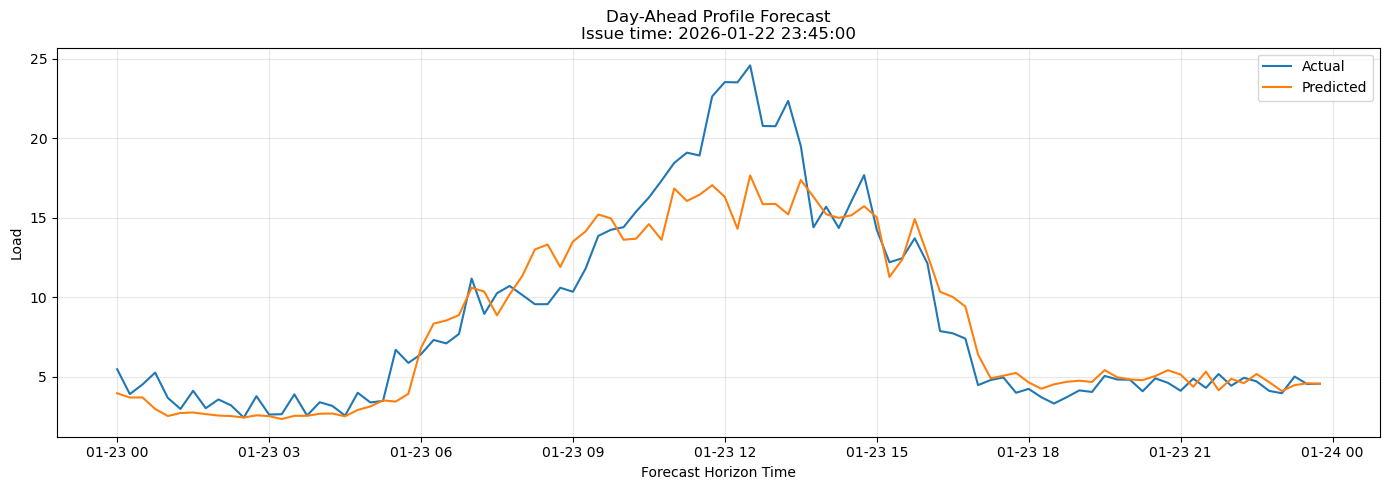

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# choose which test forecast day to plot
# 0 = first test day, 1 = second, etc.
# ==========================================
day_idx = 0

# get arrays from previous result
X_test = profile_artifacts["X_test"]
test_true_raw = profile_artifacts["test_true_raw"]
test_final_pred = profile_artifacts["test_final_pred"]

# issue timestamp for selected forecast
issue_ts = X_test.index[day_idx]

# future timestamps for next 96 steps (15-min resolution)
future_index = pd.date_range(
    start=issue_ts + pd.Timedelta(minutes=15),
    periods=96,
    freq="15min"
)

y_true_day = test_true_raw[day_idx]
y_pred_day = test_final_pred[day_idx]

# plot
plt.figure(figsize=(14, 5))
plt.plot(future_index, y_true_day, label="Actual")
plt.plot(future_index, y_pred_day, label="Predicted")
plt.title(f"Day-Ahead Profile Forecast\nIssue time: {issue_ts}")
plt.xlabel("Forecast Horizon Time")
plt.ylabel("Load")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

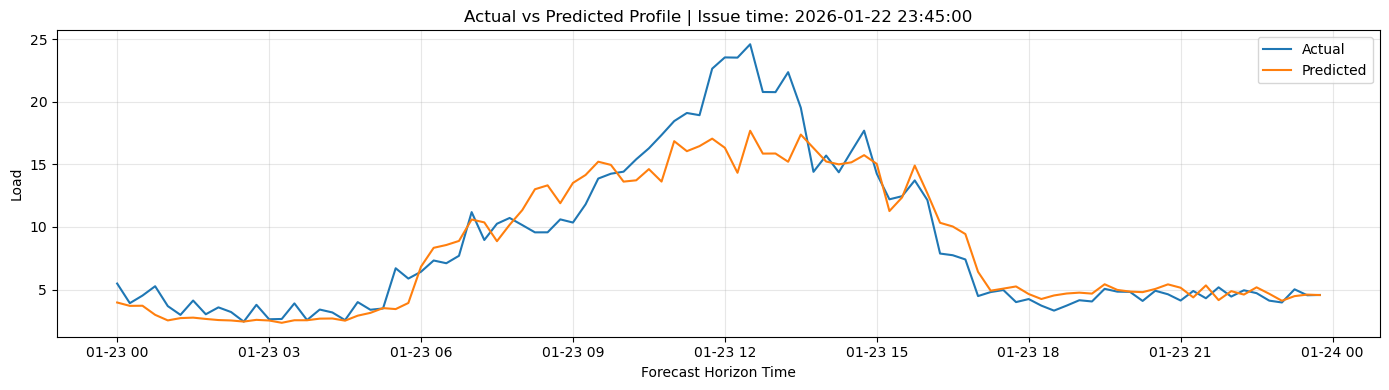

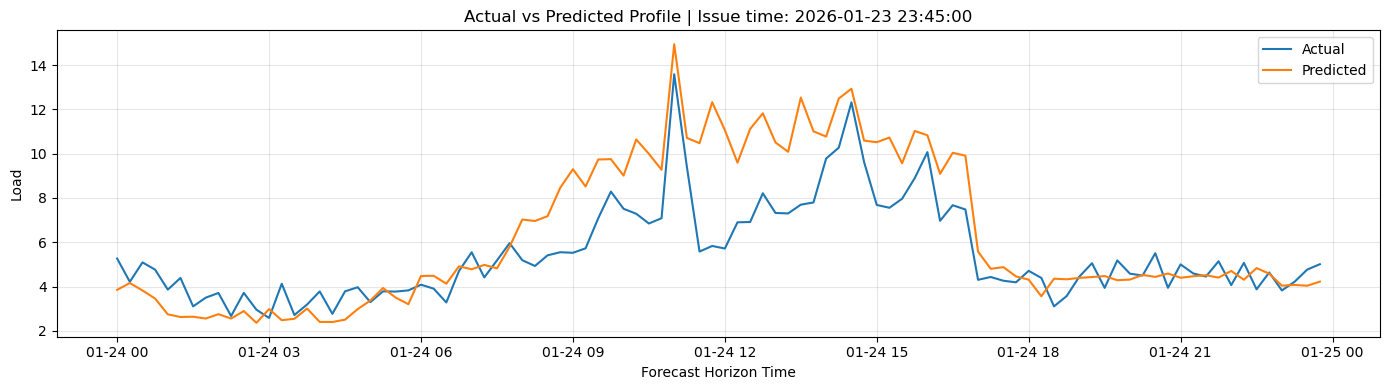

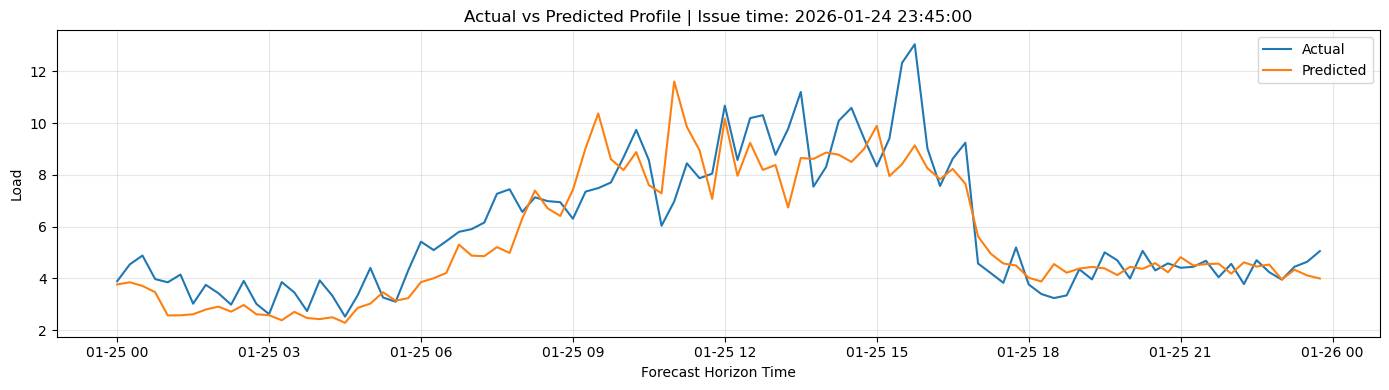

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# choose forecast rows from the test set
days_to_plot = [0, 1, 2]

X_test = profile_artifacts["X_test"]
test_true_raw = profile_artifacts["test_true_raw"]
test_final_pred = profile_artifacts["test_final_pred"]

for day_idx in days_to_plot:
    issue_ts = X_test.index[day_idx]
    future_index = pd.date_range(
        start=issue_ts + pd.Timedelta(minutes=15),
        periods=96,
        freq="15min"
    )

    y_true_day = test_true_raw[day_idx]
    y_pred_day = test_final_pred[day_idx]

    plt.figure(figsize=(14, 4))
    plt.plot(future_index, y_true_day, label="Actual")
    plt.plot(future_index, y_pred_day, label="Predicted")
    plt.title(f"Actual vs Predicted Profile | Issue time: {issue_ts}")
    plt.xlabel("Forecast Horizon Time")
    plt.ylabel("Load")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

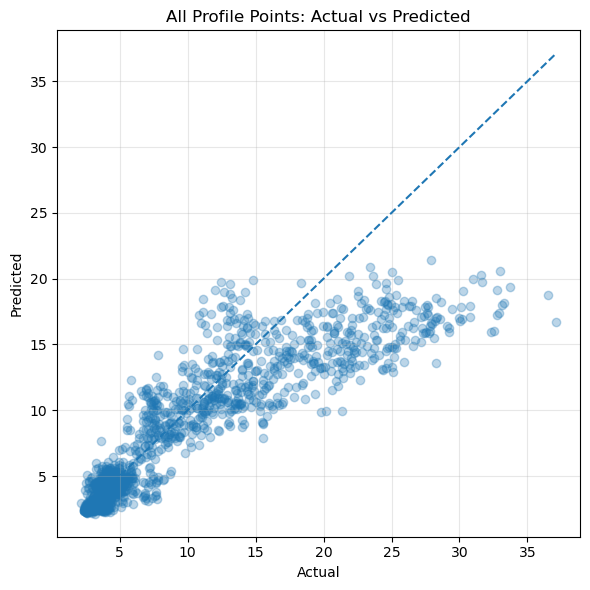

In [76]:
import matplotlib.pyplot as plt
import numpy as np

test_true_raw = profile_artifacts["test_true_raw"]
test_final_pred = profile_artifacts["test_final_pred"]

y_true_all = test_true_raw.ravel()
y_pred_all = test_final_pred.ravel()

plt.figure(figsize=(6, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.3)
min_val = min(y_true_all.min(), y_pred_all.min())
max_val = max(y_true_all.max(), y_pred_all.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("All Profile Points: Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

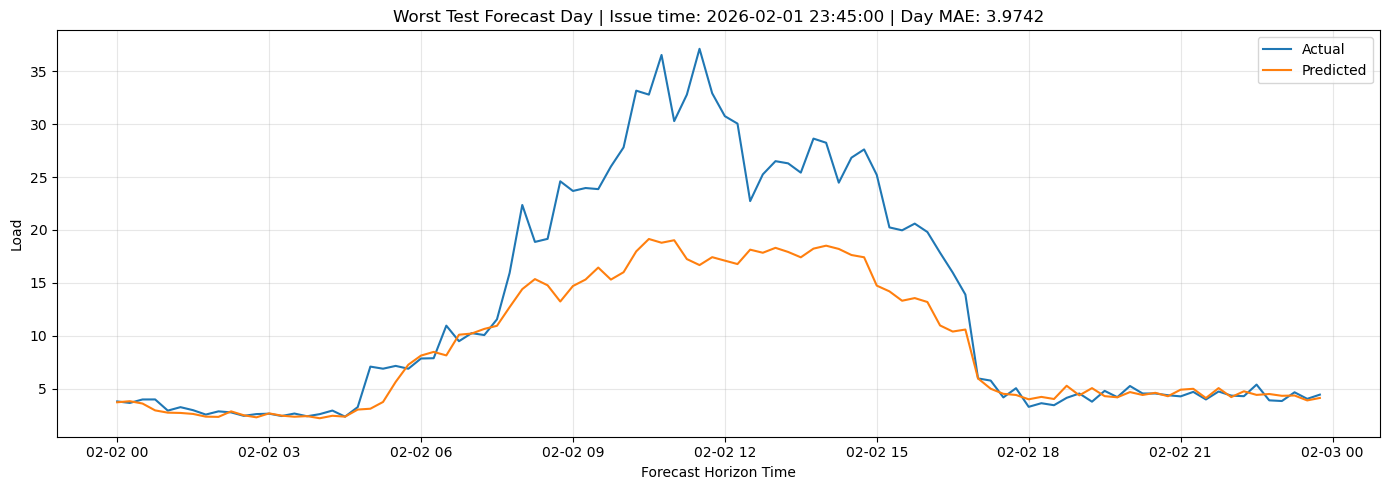

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_test = profile_artifacts["X_test"]
test_true_raw = profile_artifacts["test_true_raw"]
test_final_pred = profile_artifacts["test_final_pred"]

# compute MAE per forecast day
day_mae = np.mean(np.abs(test_true_raw - test_final_pred), axis=1)
worst_idx = np.argmax(day_mae)

issue_ts = X_test.index[worst_idx]
future_index = pd.date_range(
    start=issue_ts + pd.Timedelta(minutes=15),
    periods=96,
    freq="15min"
)

plt.figure(figsize=(14, 5))
plt.plot(future_index, test_true_raw[worst_idx], label="Actual")
plt.plot(future_index, test_final_pred[worst_idx], label="Predicted")
plt.title(f"Worst Test Forecast Day | Issue time: {issue_ts} | Day MAE: {day_mae[worst_idx]:.4f}")
plt.xlabel("Forecast Horizon Time")
plt.ylabel("Load")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

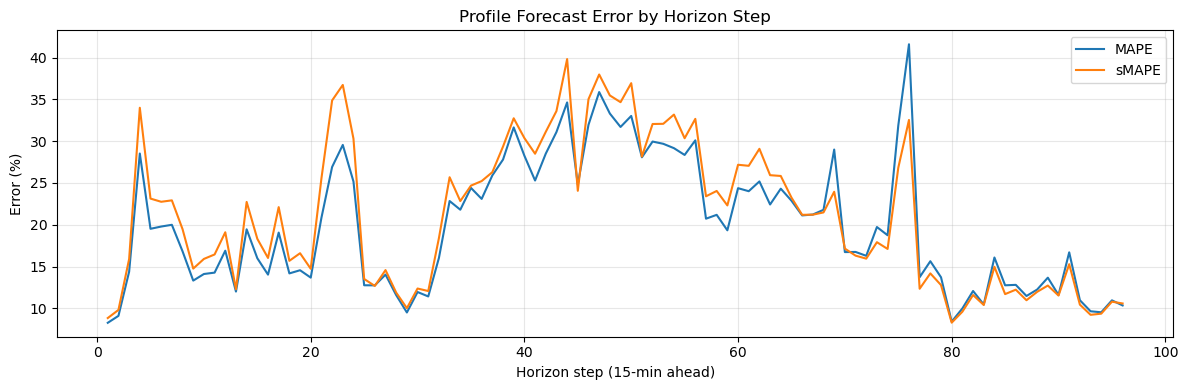

In [78]:
import matplotlib.pyplot as plt

# assumes you already have:
# test_horizon_metrics

plt.figure(figsize=(12, 4))
plt.plot(test_horizon_metrics["horizon_step"], test_horizon_metrics["MAPE"], label="MAPE")
plt.plot(test_horizon_metrics["horizon_step"], test_horizon_metrics["sMAPE"], label="sMAPE")
plt.xlabel("Horizon step (15-min ahead)")
plt.ylabel("Error (%)")
plt.title("Profile Forecast Error by Horizon Step")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

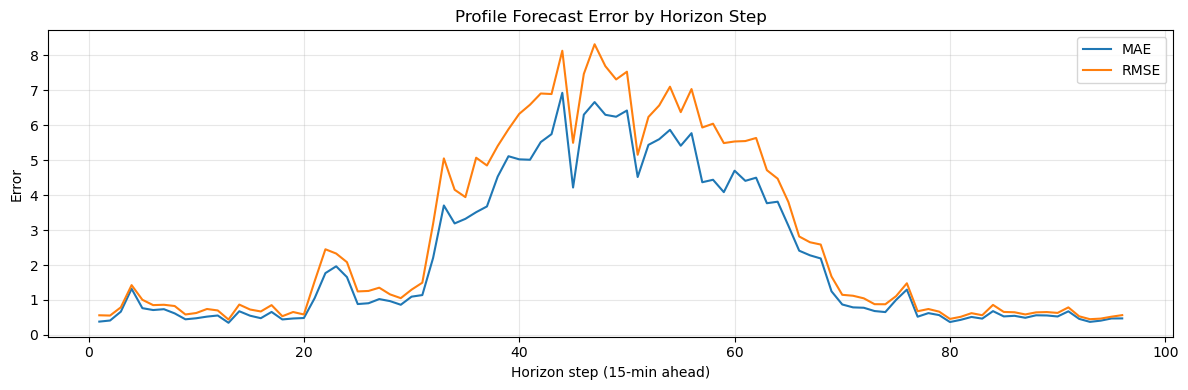

In [79]:
plt.figure(figsize=(12, 4))
plt.plot(test_horizon_metrics["horizon_step"], test_horizon_metrics["MAE"], label="MAE")
plt.plot(test_horizon_metrics["horizon_step"], test_horizon_metrics["RMSE"], label="RMSE")
plt.xlabel("Horizon step (15-min ahead)")
plt.ylabel("Error")
plt.title("Profile Forecast Error by Horizon Step")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()